# Notebook for Exercise 6

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

## (3) Four Rooms

In [ ]:
class FourRooms(object):
    """An environment with four rooms"""

    def __init__(self, max_time_steps = 459, expansion=None):
        """Initialize the Four Rooms environment"""

        self.nprandom = np.random.default_rng()

        # define the four room as a 2-D array for easy state space reference and visualization
        # 0 represents an empty cell; 1 represents a wall cell
        self.four_room_space = np.array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])
        
        # Double the size of the map if requested
        if expansion is not None:
            for i in range(expansion):
                self.four_room_space = np.repeat(np.repeat(self.four_room_space,repeats=2,axis=0),repeats=2,axis=1)

        # find the positions for all empty cells
        # note that: the origin for a 2-D numpy array is located at top-left while the origin for the FourRooms is at
        # the bottom-left. The following codes performs the re-projection.
        size_map = self.four_room_space.shape
        self.max_coord = size_map[0]-1

        empty_cells = np.where(self.four_room_space == 0.0)
        self.state_space = [[col, self.max_coord - row] for row, col in zip(empty_cells[0], empty_cells[1])]

        # define the action space
        self.action_space = ['LEFT', 'RIGHT', 'UP', 'DOWN']
        self.action_to_array = {
            'LEFT': np.array([-1, 0]),
            'RIGHT': np.array([1, 0]),
            'DOWN': np.array([0, -1]),
            'UP': np.array([0, 1])
        }


        self.start_state = [0, 0]
        self.goal_state = [self.max_coord, self.max_coord]

        self.max_time_steps = max_time_steps

        self.t = 0
        self.state = None

    def reset(self,seed=None):
        """
        Reset the agent's state to the start state [0, 0]
        """
        self.nprandom = np.random.default_rng(seed=seed)

        # reset the agent state to be [0, 0]
        self.state = self.start_state
        done = False

        # reset the time step tracker
        self.t = 0
        return self.state, done

    def step(self, act):
        """
        Steps the environment

        Input args:
            **state** (list): a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            **act** (string): a string variable in ["UP", "DOWN", "LEFT", "RIGHT"].

        Output:
            **next_state**: a list variable containing x, y integer coordinates (i.e., [1, 1])
            **reward**: an integer. it can be either 0 or 1.
        """
        # Increase the time step
        self.t += 1

        # With probability 0.8, the agent takes the correct direction.
        # With probability 0.2, the agent takes one of the two perpendicular actions.
        # For example, if the correct action is "LEFT", then
        #     - With probability 0.8, the agent takes action "LEFT";
        #     - With probability 0.1, the agent takes action "UP";
        #     - With probability 0.1, the agent takes action "DOWN".
        if self.nprandom.random() < 0.2:
            if act == "LEFT" or act == "RIGHT":
                act = self.nprandom.choice(["UP", "DOWN"], 1)[0]
            else:
                act = self.nprandom.choice(["RIGHT", "LEFT"], 1)[0]

        # Compute the next state
        next_state = self.compute_action(self.state, act)
        self.state = next_state

        # Compute the reward
        reward = 0.0 if next_state == self.goal_state else -1.0

        # Check the termination
        # If the agent reaches the goal, reward = 1, done = True
        # If the time steps reaches the maximal number, reward = 0, done = True.
        if next_state == self.goal_state or self.t >= self.max_time_steps:
            done = True
        else:
            done = False

        return self.state, reward, done

    def compute_action(self, state, act):
        """
        Input args:
            state (list): a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            act (string): a string variable (i.e., "UP"). All feasible values are ["UP", "DOWN", "LEFT", "RIGHT"].
        Output args:
            next_state (list): a list variable containing x, y integer coordinates (i.e., [1, 1])
        """
        state = np.array(state)
        next_state = state + self.action_to_array[act]
        return next_state.tolist() if next_state.tolist() in self.state_space else state.tolist()
    
# if __name__ == "__main__":
#     env = FourRooms(expansion=1)
#     print(env.four_room_space)


In [4]:
def plot_curves(arr_list, legend_list, color_list, ylabel, plot_max=200):
    """
    Args:
        arr_list (list): list of results arrays to plot
        legend_list (list): list of legends corresponding to each result array
        color_list (list): list of color corresponding to each result array
        ylabel (string): label of the Y axis

    Make sure the elements in the arr_list, legend_list, and color_list are associated with each other correctly.
    Do not forget to change the ylabel for different plots.
    """
    # Clear the current figure
    plt.clf()
    fig, ax = plt.subplots(figsize=(8, 6))

    # Set labels
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time Steps")

    # Plot results
    h_list = []
    for arr, legend, color in zip(arr_list, legend_list, color_list):
        # Compute the mean and standard error while ignoring NaN values
        mean_arr = np.nanmean(arr, axis=0)
        arr_err = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
        
        # Plot the mean
        h, = ax.plot(range(len(mean_arr)), mean_arr, color=color, label=legend)
        
        # Plot the confidence band
        arr_err = 1.96 * arr_err  # 95% confidence interval
        ax.fill_between(range(len(mean_arr)),
                        mean_arr - arr_err,
                        mean_arr + arr_err,
                        alpha=0.3, color=color)
        # Save the plot handle
        h_list.append(h)

    # Set the title (adjust as needed)
    ax.set_title("Four Room Results")
    ax.legend(handles=h_list)
    ax.set_ylim(0,plot_max)
    plt.show()

In [5]:
class TabularSARSA(object):
    """A tabular SARSA agent"""

    def __init__(self, env: FourRooms, alpha, epsilon, max_steps, gamma=1.0):
        """Init an agent that controls and learns using Tabular SARSA"""
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma
        
        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space)
        self.Q = np.zeros((self.state_num, self.action_num))

        self.action_to_idx = {a:i for i,a in enumerate(list(self.env.action_space))}
        self.idx_to_action = {i:a for i,a in enumerate(list(self.env.action_space))}

        self.tuple_state_to_idx = {tuple(s):i for i,s in enumerate(list(self.env.state_space))}
        self.idx_to_state = {i:s for i,s in enumerate(list(self.env.state_space))}

        # define the timeout
        self.max_steps = max_steps



    def behavior_policy(self, state):
        """Return an action based on the state (epsilon soft)"""
        if self.env.nprandom.random() < self.epsilon:
            action = self.env.nprandom.choice(list(self.env.action_space))
        else:
            action = self.idx_to_action[np.argmax(self.Q[self.tuple_state_to_idx[tuple(state)],:])]

        return action
    


    def calculate_target(self,r,s_prime,a_prime):
        """Calculate a learning target from a transition"""
        spidx = self.tuple_state_to_idx[tuple(s_prime)]
        apidx = self.action_to_idx[a_prime]

        target = r +  self.gamma*self.Q[spidx,apidx]

        return target



    def update(self, s, a, r, s_prime, a_prime):
        """Apply one update rule"""
        sidx = self.tuple_state_to_idx[tuple(s)]
        aidx = self.action_to_idx[a]

        U = self.calculate_target(r,s_prime,a_prime)

        self.Q[sidx,aidx] = self.Q[sidx,aidx] + self.alpha*(U - self.Q[sidx,aidx])

        return self.Q


    def run(self,seed = None):
        """Run the algorithm stepwise"""
        done = True
        num_episodes_completed = -1
        list_num_episodes = []

        for steps_taken in tqdm(range(self.max_steps),desc="Tabular SARSA Training",leave=False,position=1):
            if done:
                num_episodes_completed += 1
                state,done = self.env.reset(seed=seed)
                seed = seed + 1 if seed else None
                action = self.behavior_policy(state)
            
            next_state, reward, done = self.env.step(action)
            next_action = self.behavior_policy(next_state)
            self.update(state, action, reward, next_state, next_action)

            state = next_state
            action = next_action

            list_num_episodes.append(num_episodes_completed)
            
        return list_num_episodes
    





In [ ]:
class ApproximateSARSA(object):
    """An approximate SARSA agent using state aggregation"""

    def __init__(self, env: FourRooms, alpha, epsilon, max_steps, gamma=1.0):
        """Init an agent that controls and learns using Approximate SARSA"""
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma
        self.max_steps = max_steps
        
        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space)
        

        self.tuple_state_aggregation_lookup = {tuple(s): self.calc_state_aggregation(s) for s in self.env.state_space} #TODO: this only works when tabular...
        self.agg_state_space = list(self.tuple_state_aggregation_lookup.values())
        self.agg_state_num = len(self.agg_state_space)

        self.w = np.zeros((self.agg_state_num*self.action_num,),dtype=float)

        self.action_to_idx = {a:i for i,a in enumerate(list(self.env.action_space))}
        self.idx_to_action = {i:a for i,a in enumerate(list(self.env.action_space))}

        self.tuple_state_to_idx = {tuple(s):i for i,s in enumerate(self.agg_state_space)}
        self.idx_to_state = {i:s for i,s in enumerate(self.agg_state_space)}

        


    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        return s


    def calc_encoding_vector(self,ag_s,a):
        """Return a one-hot encoding vector for state aggreggation"""
        f = np.zeros((self.agg_state_num,self.action_num),dtype=float)
        idx = (self.tuple_state_to_idx[tuple(ag_s)],self.action_to_idx[a])
        f[idx] = 1.0

        return f.flatten()
    
    def calc_Q(self,ag_s,a):
        """Calculate Q"""
        fsa = self.calc_encoding_vector(ag_s,a)
        Qsa = np.dot(self.w, fsa)
        return Qsa







    def behavior_policy(self, state):
        """Return an action based on the state (epsilon soft)"""
        ag_state = self.tuple_state_aggregation_lookup[tuple(state)]

        if self.env.nprandom.random() < self.epsilon:
            action = self.env.nprandom.choice(list(self.env.action_space))
        else:
            action = self.idx_to_action[np.argmax([self.calc_Q(ag_state,a) for a in self.env.action_space])]

        return action
    


    def calculate_target(self,r,s_prime,a_prime):
        """Calculate a learning target from a transition"""
        ag_s_prime = self.tuple_state_aggregation_lookup[tuple(s_prime)]

        target = r +  self.gamma*self.calc_Q(ag_s_prime,a_prime)

        return target



    def update(self, s, a, r, s_prime, a_prime):
        """Apply one update rule"""
        ag_s = self.tuple_state_aggregation_lookup[tuple(s)]

        U = self.calculate_target(r,s_prime,a_prime)
        L = U-self.calc_Q(ag_s,a) 
        gradQ = self.calc_encoding_vector(ag_s,a)

        self.w = self.w + self.alpha*(L)*gradQ

        return self.calc_Q(ag_s,a)


    def run(self,seed = None):
        """Run the algorithm stepwise"""
        done = True
        num_episodes_completed = -1
        list_num_episodes = []

        for steps_taken in tqdm(range(self.max_steps),desc="Approx SARSA Training",leave=False,position=1):
            if done:
                num_episodes_completed += 1
                state,done = self.env.reset(seed=seed)
                seed = seed + 1 if seed else None
                action = self.behavior_policy(state)
            
            next_state, reward, done = self.env.step(action)
            next_action = self.behavior_policy(next_state)
            self.update(state, action, reward, next_state, next_action)

            state = next_state
            action = next_action

            list_num_episodes.append(num_episodes_completed)
            
        return list_num_episodes
    





In [7]:
class TileSARSA(ApproximateSARSA):
    """An approximate SARSA agent using state aggregation in 2x2 tiles"""

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        xtile = int(np.floor(x/2))
        ytile = int(np.floor(y/2))

        ag_s = [xtile,ytile]
        return ag_s

if __name__ == "__main__":
    print(TileSARSA.calc_state_aggregation("",[4,2]))


[2, 1]


In [8]:
class RoomSARSA(ApproximateSARSA):
    """An approximate SARSA agent using state aggregation by room"""

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        
        if x <= 5:
            if y <= 5:
                ag_s = [0,0]
            else:
                ag_s = [0,1]
        else:
            if y <= 4:
                ag_s = [1,0]
            else:
                ag_s = [1,1]
                
        return ag_s

if __name__ == "__main__":
    print(RoomSARSA.calc_state_aggregation("",[4,2]))


[0, 0]


In [ ]:
class FeatureSARSA(ApproximateSARSA):
    """An approximate SARSA agent using features"""

    def __init__(self, env: FourRooms, alpha, epsilon, max_steps, gamma=1.0, min_w = -1e12, max_w = 1e12):
        """Init the agent using features"""
        super().__init__(env, alpha, epsilon, max_steps, gamma)

        self.num_features = 3
        self.w = np.zeros((self.num_features+self.action_num,))

        self.min_w = min_w
        self.max_w = max_w

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        ag_s = np.array([x,y,1],dtype=float)
        return ag_s
    
    def calc_encoding_vector(self, ag_s, a):
        one_hot_a = np.zeros((self.action_num,),dtype=float)
        one_hot_a[self.action_to_idx[a]] = 1

        fsa = np.hstack([ag_s,one_hot_a])
        return fsa
    
    def update(self, s, a, r, s_prime, a_prime):
        Q = super().update(s, a, r, s_prime, a_prime)
        self.w = np.clip(self.w,self.min_w,self.max_w) 
        return Q

if __name__ == "__main__":
    s = [4,2]
    print(f"fs: {FeatureSARSA.calc_state_aggregation("",s)}")

    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0
    total_steps = 1000
    env = FourRooms(max_time_steps=total_steps)
    agent = FeatureSARSA(env, alpha, epsilon, total_steps, gamma)

    fs = agent.calc_state_aggregation(s)
    print(f"fsa: {agent.calc_encoding_vector(fs,"RIGHT")}")

    print(f"w: {agent.w}")
    


fs: [4. 2. 1.]
fsa: [4. 2. 1. 0. 1. 0. 0.]
w: [0. 0. 0. 0. 0. 0. 0.]


In [ ]:
class NormFeatureSARSA(ApproximateSARSA):
    """An approximate SARSA agent using normalized features"""

    def __init__(self, env: FourRooms, alpha, epsilon, max_steps, gamma=1.0, min_w = -1e12, max_w = 1e12):
        """Init the agent"""
        self.max_x = 10
        self.max_y = 10
        
        super().__init__(env, alpha, epsilon, max_steps, gamma)

        self.num_features = 3
        self.w = np.zeros((self.num_features+self.action_num,))

        self.min_w = min_w
        self.max_w = max_w

        self.alpha *= self.max_x

        

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        ag_s = np.array([x/self.max_x,y/self.max_y,1],dtype=float)
        return ag_s
    
    def calc_encoding_vector(self, ag_s, a):
        """Return the encoding vector"""
        one_hot_a = np.zeros((self.action_num,),dtype=float)
        one_hot_a[self.action_to_idx[a]] = 1

        fsa = np.hstack([ag_s,one_hot_a])
        return fsa
    
    def update(self, s, a, r, s_prime, a_prime):
        """Update the weights"""
        Q = super().update(s, a, r, s_prime, a_prime)
        self.w = np.clip(self.w,self.min_w,self.max_w) 
        return Q

if __name__ == "__main__":
    s = [4,2]
    

    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0
    total_steps = 1000
    env = FourRooms(max_time_steps=total_steps)
    agent = NormFeatureSARSA(env, alpha, epsilon, total_steps, gamma)

    fs = agent.calc_state_aggregation(s)
    print(f"fs: {agent.calc_state_aggregation(s)}")
    print(f"fsa: {agent.calc_encoding_vector(fs,"RIGHT")}")

    print(f"w: {agent.w}")
    


fs: [0.4 0.2 1. ]
fsa: [0.4 0.2 1.  0.  1.  0.  0. ]
w: [0. 0. 0. 0. 0. 0. 0.]


In [16]:
class DistFeatureSARSA(ApproximateSARSA):
    """An approximate SARSA agent using features"""

    def __init__(self, env: FourRooms, alpha, epsilon, max_steps, gamma=1.0, min_w = -1e12, max_w = 1e12):
        super().__init__(env, alpha, epsilon, max_steps, gamma)

        self.num_features = 4
        self.w = np.zeros((self.num_features+self.action_num,))

        self.min_w = min_w
        self.max_w = max_w

    def calc_distance(self,s):
        x,y = s
        
        # Find starting room
        if x <= 5:
            if y <= 5:
                room = [0,0]
            else:
                room = [0,1]
        else:
            if y <= 4:
                room = [1,0]
            else:
                room = [1,1]

        # Calculate distance
        d = 0
        if room == [0,0]:
            door = [1,5]
            d += abs(door[0]-x) + abs(door[1]-y)
            room == [0,1]

        if room == [0,1]:
            door = [5,8]
            d += abs(door[0]-x) + abs(door[1]-y)
            room == [1,1]

        if room == [1,0]:
            door = [4,8]
            d += abs(door[0]-x) + abs(door[1]-y)
            room == [1,1]

        if room == [1,1]:
            goal = [10,10]
            d += abs(goal[0]-x) + abs(goal[1]-y)
                
        return d

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        d = self.calc_distance(s)
        ag_s = np.array([d,x,y,1],dtype=float)
        return ag_s
    
    def calc_encoding_vector(self, ag_s, a):
        one_hot_a = np.zeros((self.action_num,),dtype=float)
        one_hot_a[self.action_to_idx[a]] = 1

        fsa = np.hstack([ag_s,one_hot_a])
        return fsa
    
    def update(self, s, a, r, s_prime, a_prime):
        Q = super().update(s, a, r, s_prime, a_prime)
        self.w = np.clip(self.w,self.min_w,self.max_w) 
        return Q
    


if __name__ == "__main__":
    s = [4,2]
    print(f"fs: {FeatureSARSA.calc_state_aggregation("",s)}")

    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0
    total_steps = 1000
    env = FourRooms(max_time_steps=total_steps)
    agent = FeatureSARSA(env, alpha, epsilon, total_steps, gamma)

    fs = agent.calc_state_aggregation(s)
    print(f"fsa: {agent.calc_encoding_vector(fs,"RIGHT")}")

    print(f"w: {agent.w}")
    


fs: [4. 2. 1.]
fsa: [4. 2. 1. 0. 1. 0. 0.]
w: [0. 0. 0. 0. 0. 0. 0.]


In [ ]:
class ApproxQLearning(ApproximateSARSA):
        """An agent that uses approximate Q-Learning"""

        def calculate_target(self,r,s_prime):
                """Calculate a learning target from a transition"""
                ag_s_prime = self.calc_state_aggregation(s_prime)

                target = r +  self.gamma*np.max([self.calc_Q(ag_s_prime,a_prime) for a_prime in self.env.action_space])

                return target
        
        def update(self, s, a, r, s_prime):
                """Apply one update rule"""
                ag_s = self.tuple_state_aggregation_lookup[tuple(s)]

                U = self.calculate_target(r,s_prime)
                L = U-self.calc_Q(ag_s,a) 
                gradQ = self.calc_encoding_vector(ag_s,a)

                self.w = self.w + self.alpha*(L)*gradQ

                return self.calc_Q(ag_s,a)


        def run(self,seed = None):
                """Run the algorithm stepwise"""
                done = True
                num_episodes_completed = -1
                list_num_episodes = []

                for steps_taken in tqdm(range(self.max_steps),desc="Approx SARSA Training",leave=False,position=1):
                        if done:
                                num_episodes_completed += 1
                                state,done = self.env.reset(seed=seed)
                                seed = seed + 1 if seed else None
                                
                        action = self.behavior_policy(state)
                        next_state, reward, done = self.env.step(action)
                        self.update(state, action, reward, next_state)

                        state = next_state

                        list_num_episodes.append(num_episodes_completed)
                
                return list_num_episodes

In [25]:
class TileQLearning(ApproxQLearning):
    """An approximate Q-learning agent using state aggregation in 2x2 tiles"""

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        xtile = int(np.floor(x/2))
        ytile = int(np.floor(y/2))

        ag_s = [xtile,ytile]
        return ag_s

if __name__ == "__main__":
    print(TileQLearning.calc_state_aggregation("",[4,2]))


[2, 1]


In [ ]:
class RoomQLearning(ApproxQLearning):
    """An approximate Q-Learning agent that aggregates by room"""

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        
        if x <= 5:
            if y <= 5:
                ag_s = [0,0]
            else:
                ag_s = [0,1]
        else:
            if y <= 4:
                ag_s = [1,0]
            else:
                ag_s = [1,1]
                
        return ag_s

if __name__ == "__main__":
    print(RoomQLearning.calc_state_aggregation("",[4,2]))


[0, 0]


In [ ]:
class TileNSARSA(ApproximateSARSA):
    """An approximate SARSA agent using state aggregation in n x n tiles"""

    def __init__(self, env, alpha, epsilon, max_steps, gamma=1, n=2):
        """Init the agent"""
        self.n = n
        super().__init__(env, alpha, epsilon, max_steps, gamma)
        

    def calc_state_aggregation(self,s):
        """Return the aggregated state"""
        x,y = s
        xtile = int(np.floor(x/self.n))
        ytile = int(np.floor(y/self.n))

        ag_s = [xtile,ytile]
        return ag_s


Experiment: Tabular SARSA:   0%|          | 0/10 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

...

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

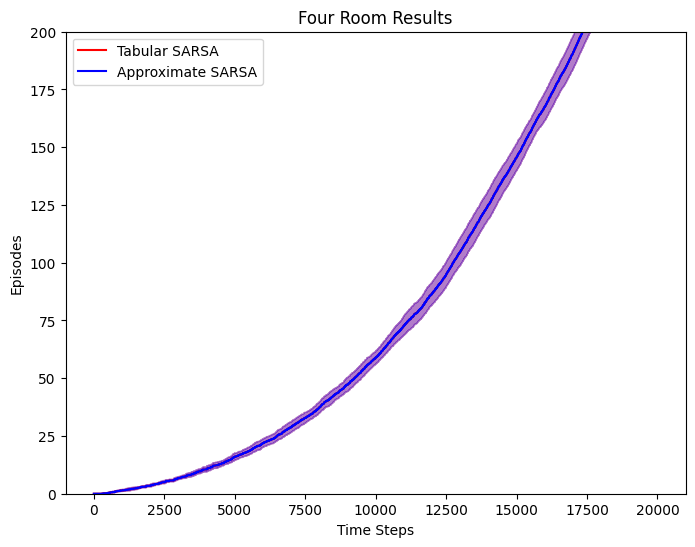

In [69]:
def run_experiment_1(run_num, total_steps, start_seed = None, plot_max=200):
    
    # create the environment
    env = FourRooms(max_time_steps=total_steps)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    run_seed_shift = 1000

    # create the Tabular SARSA Results
    tabsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tabular SARSA",leave=True, position=0):
        # run for each trial
        controller_tabsarsa = TabularSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tabsarsa.run(seed=seed)
        # append the results
        tabsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA Results
    appsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Approx SARSA",leave=True, position=0):
        # run for each trial
        controller_appsarsa = ApproximateSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_appsarsa.run(seed=seed)
        # append the results
        appsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift
    

    # # create the DP results list
    # dp_results_list = []
    # seed = start_seed
    # dp_runs = 1
    # if not enable_stochastic_wind:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000
    # else:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP (Stochastic)",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = Stochastic_DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000

    # true_value = np.max(controller_dp.Q[controller_dp.tuple_state_to_idx[tuple(controller_dp.env.start_state)],:])
    # print(f"True Starter State Value: {true_value}")


    # Convert to np arrays
    tabsarsa_array = np.array(tabsarsa_results_list)
    appsarsa_array = np.array(appsarsa_results_list)
    
    # Plot the results
    plot_curves(
        [tabsarsa_array, appsarsa_array],
        ['Tabular SARSA', 'Approximate SARSA'],
        ['r', 'b', 'g', 'y', 'm'],
        "Episodes",
        plot_max=plot_max
    )



if __name__ == "__main__":
    # Experiment 1

    # set randomness
    seed = 1234

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 20000
    
    
    # run SARSA and Q Learning
    run_experiment_1(trial_num, max_time_steps, start_seed=seed)

Experiment: Tabular SARSA:   0%|          | 0/10 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

...

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

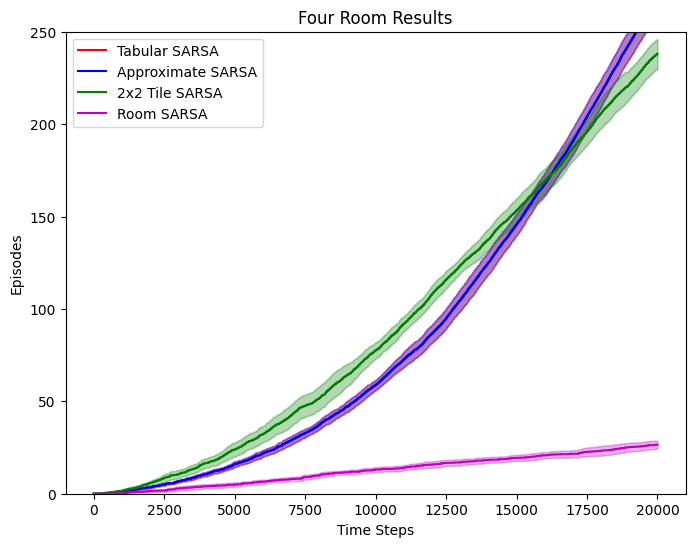

In [71]:
def run_experiment_2(run_num, total_steps, start_seed = None, plot_max=250):
    
    # create the environment
    env = FourRooms(max_time_steps=total_steps)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    run_seed_shift = 1000

    # create the Tabular SARSA Results
    tabsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tabular SARSA",leave=True, position=0):
        # run for each trial
        controller_tabsarsa = TabularSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tabsarsa.run(seed=seed)
        # append the results
        tabsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA Results
    appsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Approx SARSA",leave=True, position=0):
        # run for each trial
        controller_appsarsa = ApproximateSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_appsarsa.run(seed=seed)
        # append the results
        appsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with 2x2 Tile Results
    tilesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile SARSA",leave=True, position=0):
        # run for each trial
        controller_tilesarsa = TileSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tilesarsa.run(seed=seed)
        # append the results
        tilesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Rooms Results
    roomsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Room SARSA",leave=True, position=0):
        # run for each trial
        controller_roomsarsa = RoomSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_roomsarsa.run(seed=seed)
        # append the results
        roomsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift
    

    # # create the DP results list
    # dp_results_list = []
    # seed = start_seed
    # dp_runs = 1
    # if not enable_stochastic_wind:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000
    # else:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP (Stochastic)",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = Stochastic_DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000

    # true_value = np.max(controller_dp.Q[controller_dp.tuple_state_to_idx[tuple(controller_dp.env.start_state)],:])
    # print(f"True Starter State Value: {true_value}")


    # Convert to np arrays
    tabsarsa_array = np.array(tabsarsa_results_list)
    appsarsa_array = np.array(appsarsa_results_list)
    tilesarsa_array = np.array(tilesarsa_results_list)
    roomsarsa_array = np.array(roomsarsa_results_list)
    
    # Plot the results
    plot_curves(
        [tabsarsa_array, appsarsa_array, tilesarsa_array, roomsarsa_array],
        ['Tabular SARSA', 'Approximate SARSA', '2x2 Tile SARSA', 'Room SARSA'],
        ['r', 'b', 'g', 'm', 'y'],
        "Episodes",
        plot_max=plot_max
    )



if __name__ == "__main__":
    # Experiment 2

    # set randomness
    seed = 1234

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 20000
    
    
    # run SARSA and Q Learning
    run_experiment_2(trial_num, max_time_steps, start_seed=seed)

Experiment: Tabular SARSA:   0%|          | 0/10 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

...

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

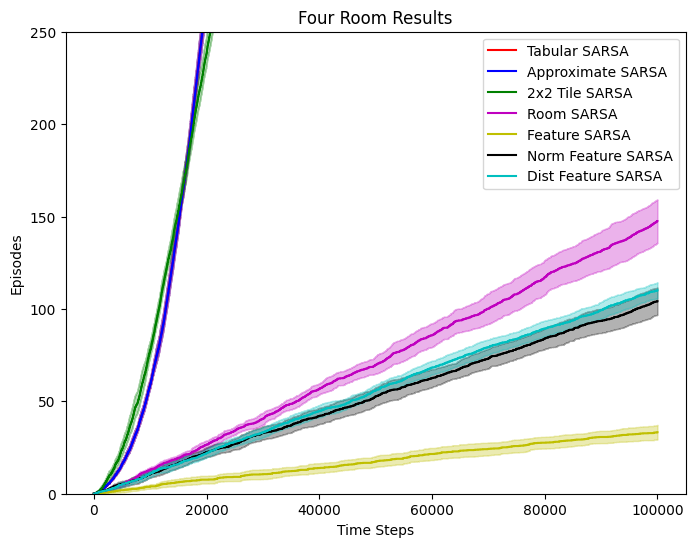

In [21]:
def run_experiment_3(run_num, total_steps, start_seed = None, plot_max=250):
    
    # create the environment
    env = FourRooms(max_time_steps=total_steps)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    run_seed_shift = 1000

    # create the Tabular SARSA Results
    tabsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tabular SARSA",leave=True, position=0):
        # run for each trial
        controller_tabsarsa = TabularSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tabsarsa.run(seed=seed)
        # append the results
        tabsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA Results
    appsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Approx SARSA",leave=True, position=0):
        # run for each trial
        controller_appsarsa = ApproximateSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_appsarsa.run(seed=seed)
        # append the results
        appsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with 2x2 Tile Results
    tilesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile SARSA",leave=True, position=0):
        # run for each trial
        controller_tilesarsa = TileSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tilesarsa.run(seed=seed)
        # append the results
        tilesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Rooms Results
    roomsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Room SARSA",leave=True, position=0):
        # run for each trial
        controller_roomsarsa = RoomSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_roomsarsa.run(seed=seed)
        # append the results
        roomsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Features Results
    featuresarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Feature SARSA",leave=True, position=0):
        # run for each trial
        controller_featuresarsa = FeatureSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_featuresarsa.run(seed=seed)
        # append the results
        featuresarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Norm Features Results
    normfeaturesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Norm Feature SARSA",leave=True, position=0):
        # run for each trial
        controller_normfeaturesarsa = NormFeatureSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_normfeaturesarsa.run(seed=seed)
        # append the results
        normfeaturesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift
    
    # create the Approximate SARSA with Norm Features Results
    distfeaturesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Dist Feature SARSA",leave=True, position=0):
        # run for each trial
        controller_distfeaturesarsa = DistFeatureSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_distfeaturesarsa.run(seed=seed)
        # append the results
        distfeaturesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # # create the DP results list
    # dp_results_list = []
    # seed = start_seed
    # dp_runs = 1
    # if not enable_stochastic_wind:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000
    # else:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP (Stochastic)",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = Stochastic_DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000

    # true_value = np.max(controller_dp.Q[controller_dp.tuple_state_to_idx[tuple(controller_dp.env.start_state)],:])
    # print(f"True Starter State Value: {true_value}")


    # Convert to np arrays
    tabsarsa_array = np.array(tabsarsa_results_list)
    appsarsa_array = np.array(appsarsa_results_list)
    tilesarsa_array = np.array(tilesarsa_results_list)
    roomsarsa_array = np.array(roomsarsa_results_list)
    featuresarsa_array = np.array(featuresarsa_results_list)
    normfeaturesarsa_array = np.array(normfeaturesarsa_results_list)
    distfeaturesarsa_array = np.array(distfeaturesarsa_results_list)
    
    # Plot the results
    plot_curves(
        [tabsarsa_array, appsarsa_array, tilesarsa_array, roomsarsa_array, featuresarsa_array, normfeaturesarsa_array, distfeaturesarsa_array],
        ['Tabular SARSA', 'Approximate SARSA', '2x2 Tile SARSA', 'Room SARSA', 'Feature SARSA', 'Norm Feature SARSA', 'Dist Feature SARSA'],
        ['r', 'b', 'g', 'm', 'y', 'k', 'c'],
        "Episodes",
        plot_max=plot_max
    )



if __name__ == "__main__":
    # Experiment 3

    # set randomness
    seed = 1234

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 100000
    
    
    # run SARSA and Q Learning
    run_experiment_3(trial_num, max_time_steps, start_seed=seed)

Experiment: Tabular SARSA:   0%|          | 0/10 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

...

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/20000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

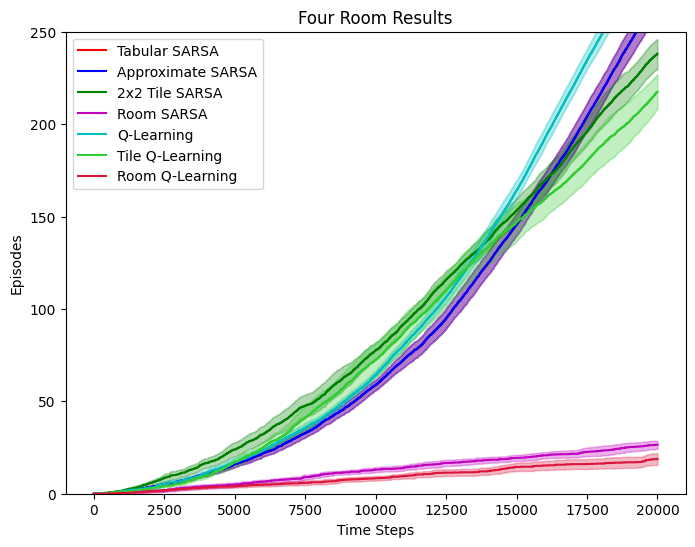

In [28]:
def run_experiment_4(run_num, total_steps, start_seed = None, plot_max=250):
    
    # create the environment
    env = FourRooms(max_time_steps=total_steps)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    run_seed_shift = 1000

    # create the Tabular SARSA Results
    tabsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tabular SARSA",leave=True, position=0):
        # run for each trial
        controller_tabsarsa = TabularSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tabsarsa.run(seed=seed)
        # append the results
        tabsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA Results
    appsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Approx SARSA",leave=True, position=0):
        # run for each trial
        controller_appsarsa = ApproximateSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_appsarsa.run(seed=seed)
        # append the results
        appsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with 2x2 Tile Results
    tilesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile SARSA",leave=True, position=0):
        # run for each trial
        controller_tilesarsa = TileSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tilesarsa.run(seed=seed)
        # append the results
        tilesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Rooms Results
    roomsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Room SARSA",leave=True, position=0):
        # run for each trial
        controller_roomsarsa = RoomSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_roomsarsa.run(seed=seed)
        # append the results
        roomsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate Q-Learning Results
    qlearn_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Q-Learning",leave=True, position=0):
        # run for each trial
        controller_qlearn = ApproxQLearning(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_qlearn.run(seed=seed)
        # append the results
        qlearn_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Tile Q-Learning Results
    tileqlearn_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile Q-Learning",leave=True, position=0):
        # run for each trial
        controller_tileqlearn = TileQLearning(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tileqlearn.run(seed=seed)
        # append the results
        tileqlearn_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Room Q-Learning Results
    roomqlearn_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Room Q-Learning",leave=True, position=0):
        # run for each trial
        controller_roomqlearn = RoomQLearning(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_roomqlearn.run(seed=seed)
        # append the results
        roomqlearn_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift
    

    # # create the DP results list
    # dp_results_list = []
    # seed = start_seed
    # dp_runs = 1
    # if not enable_stochastic_wind:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000
    # else:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP (Stochastic)",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = Stochastic_DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000

    # true_value = np.max(controller_dp.Q[controller_dp.tuple_state_to_idx[tuple(controller_dp.env.start_state)],:])
    # print(f"True Starter State Value: {true_value}")


    # Convert to np arrays
    tabsarsa_array = np.array(tabsarsa_results_list)
    appsarsa_array = np.array(appsarsa_results_list)
    tilesarsa_array = np.array(tilesarsa_results_list)
    roomsarsa_array = np.array(roomsarsa_results_list)
    
    qlearn_array = np.array(qlearn_results_list)
    tileqlearn_array = np.array(tileqlearn_results_list)
    roomqlearn_array = np.array(roomqlearn_results_list)
    
    # Plot the results
    plot_curves(
        [tabsarsa_array, appsarsa_array, tilesarsa_array, roomsarsa_array, qlearn_array, tileqlearn_array, roomqlearn_array],
        ['Tabular SARSA', 'Approximate SARSA', '2x2 Tile SARSA', 'Room SARSA', 'Q-Learning', 'Tile Q-Learning', 'Room Q-Learning'],
        ['r', 'b', 'g', 'm', 'c', 'limegreen','crimson'],
        "Episodes",
        plot_max=plot_max
    )



if __name__ == "__main__":
    # Experiment 4

    # set randomness
    seed = 1234

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 20000
    
    
    # run SARSA and Q Learning
    run_experiment_4(trial_num, max_time_steps, start_seed=seed)

Experiment: Tabular SARSA:   0%|          | 0/10 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

...

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

c:\workspace\cs5180rl-main\cs5180rl\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


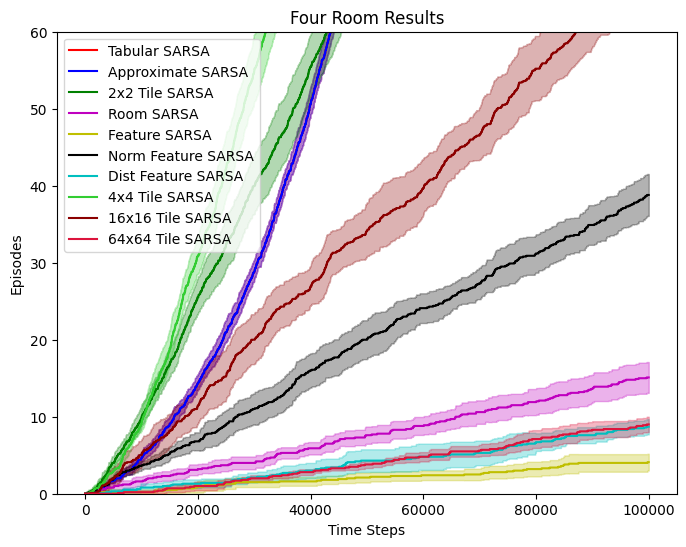

Experiment: Tabular SARSA:   0%|          | 0/10 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Tabular SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

...

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Approx SARSA Training:   0%|          | 0/100000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

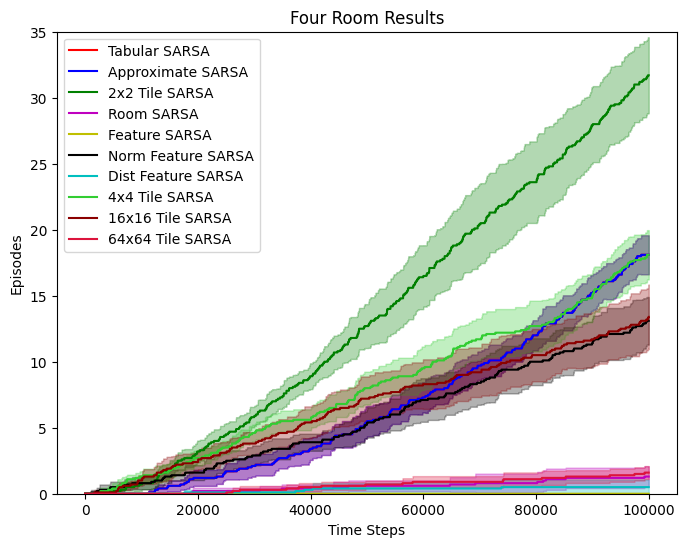

In [53]:
def run_experiment_5(run_num, total_steps, expansion = None, start_seed = None, plot_max=250):
    
    # create the environment
    env = FourRooms(max_time_steps=total_steps,expansion=expansion)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    run_seed_shift = 1000

    # create the Tabular SARSA Results
    tabsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tabular SARSA",leave=True, position=0):
        # run for each trial
        controller_tabsarsa = TabularSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tabsarsa.run(seed=seed)
        # append the results
        tabsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA Results
    appsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Approx SARSA",leave=True, position=0):
        # run for each trial
        controller_appsarsa = ApproximateSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_appsarsa.run(seed=seed)
        # append the results
        appsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with 2x2 Tile Results
    tilesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile SARSA",leave=True, position=0):
        # run for each trial
        controller_tilesarsa = TileSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_tilesarsa.run(seed=seed)
        # append the results
        tilesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Rooms Results
    roomsarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Room SARSA",leave=True, position=0):
        # run for each trial
        controller_roomsarsa = RoomSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_roomsarsa.run(seed=seed)
        # append the results
        roomsarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Features Results
    featuresarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Feature SARSA",leave=True, position=0):
        # run for each trial
        controller_featuresarsa = FeatureSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_featuresarsa.run(seed=seed)
        # append the results
        featuresarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # create the Approximate SARSA with Norm Features Results
    normfeaturesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Norm Feature SARSA",leave=True, position=0):
        # run for each trial
        controller_normfeaturesarsa = NormFeatureSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_normfeaturesarsa.run(seed=seed)
        # append the results
        normfeaturesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift
    
    # create the Approximate SARSA with Norm Features Results
    distfeaturesarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Dist Feature SARSA",leave=True, position=0):
        # run for each trial
        controller_distfeaturesarsa = DistFeatureSARSA(env, alpha, epsilon, total_steps, gamma)
        episodes = controller_distfeaturesarsa.run(seed=seed)
        # append the results
        distfeaturesarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift



    # create the Approximate SARSA with 2x2 Tile Results
    tile4sarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile 4 SARSA",leave=True, position=0):
        # run for each trial
        controller_tile4sarsa = TileNSARSA(env, alpha, epsilon, total_steps, gamma,n=4)
        episodes = controller_tile4sarsa.run(seed=seed)
        # append the results
        tile4sarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    tile16sarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile 16 SARSA",leave=True, position=0):
        # run for each trial
        controller_tile16sarsa = TileNSARSA(env, alpha, epsilon, total_steps, gamma,n=16)
        episodes = controller_tile16sarsa.run(seed=seed)
        # append the results
        tile16sarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    tile64sarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Tile 64 SARSA",leave=True, position=0):
        # run for each trial
        controller_tile64sarsa = TileNSARSA(env, alpha, epsilon, total_steps, gamma,n=64)
        episodes = controller_tile64sarsa.run(seed=seed)
        # append the results
        tile64sarsa_results_list.append(episodes[0:total_steps])
        seed += run_seed_shift

    # # create the DP results list
    # dp_results_list = []
    # seed = start_seed
    # dp_runs = 1
    # if not enable_stochastic_wind:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000
    # else:
    #     for _ in tqdm(range(dp_runs),desc="Experiment: DP (Stochastic)",leave=True, position=0):
    #         # run for each trial
    #         controller_dp = Stochastic_DP_Learner(env, alpha, epsilon, gamma, timeout)
    #         controller_dp.learn(threshold=1e-3,max_iter=1000)
    #         episodes = controller_dp.run(seed=seed)
    #         # append the results
    #         dp_results_list.append(episodes[0:timeout])
    #         seed += 1000

    # true_value = np.max(controller_dp.Q[controller_dp.tuple_state_to_idx[tuple(controller_dp.env.start_state)],:])
    # print(f"True Starter State Value: {true_value}")


    # Convert to np arrays
    tabsarsa_array = np.array(tabsarsa_results_list)
    appsarsa_array = np.array(appsarsa_results_list)
    tilesarsa_array = np.array(tilesarsa_results_list)
    roomsarsa_array = np.array(roomsarsa_results_list)
    featuresarsa_array = np.array(featuresarsa_results_list)
    normfeaturesarsa_array = np.array(normfeaturesarsa_results_list)
    distfeaturesarsa_array = np.array(distfeaturesarsa_results_list)
    
    tile4sarsa_array = np.array(tile4sarsa_results_list)
    tile16sarsa_array = np.array(tile16sarsa_results_list)
    tile64sarsa_array = np.array(tile64sarsa_results_list)
    
    # Plot the results
    plot_curves(
        [tabsarsa_array, appsarsa_array, tilesarsa_array, roomsarsa_array, featuresarsa_array, normfeaturesarsa_array, distfeaturesarsa_array, tile4sarsa_array, tile16sarsa_array, tile64sarsa_array],
        ['Tabular SARSA', 'Approximate SARSA', '2x2 Tile SARSA', 'Room SARSA', 'Feature SARSA', 'Norm Feature SARSA', 'Dist Feature SARSA','4x4 Tile SARSA','16x16 Tile SARSA','64x64 Tile SARSA'],
        ['r', 'b', 'g', 'm', 'y', 'k', 'c', 'limegreen', 'darkred', 'crimson'],
        "Episodes",
        plot_max=plot_max
    )



if __name__ == "__main__":
    # Experiment 5

    # set randomness
    seed = 1234

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 100000
    
    
    # run SARSA and Q Learning
    run_experiment_5(trial_num, max_time_steps, start_seed=seed, expansion=1, plot_max=60)
    run_experiment_5(trial_num, max_time_steps, start_seed=seed, expansion=2, plot_max=35)